
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_13_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Memorias asociativas con redes de Hopfield

## Objetivo

Construir una red de Hopfield capaz de almacenar imágenes binarias y recuperar una imagen original a partir de una versión con ruido.


# Actividades

Para las imágenes dadas, construya un algoritmo que permita recuperar la imagen original a partir de una imagen perturbada.

Debe implementar funciones para:

1. Convertir una imagen binaria en un vector de estados.
2. Calcular la matriz de pesos de Hopfield.
3. Calcular el campo local que siente una neurona.
4. Actualizar el estado de una neurona.
5. Calcular la energía total de la red.
6. Aplicar ruido a una imagen.
7. Recuperar la imagen mediante actualización asincrónica aleatoria.

---

# Modelo de Hopfield

La matriz de pesos se define mediante la regla de Hebb:

$$
w_{ij}=\frac{1}{N}\sum_{\mu=1}^{P}\xi_i^\mu \xi_j^\mu
$$

con:

$$
w_{ii}=0
$$

donde:

- $N$ es el número total de píxeles,
- $P$ es el número de patrones almacenados,
- $\xi^\mu$ es el patrón $\mu$-ésimo.

---

# Campo local

Para una neurona $i$, el campo local es:

$$
h_i=\sum_j w_{ij}s_j
$$

Este campo representa la influencia colectiva que todas las demás neuronas ejercen sobre la neurona $i$.

---

# Regla de actualización

La actualización determinista de Hopfield es:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

Si:

$$
h_i>0
$$

entonces:

$$
s_i=1
$$

Si:

$$
h_i<0
$$

entonces:

$$
s_i=-1
$$

---

# Energía de la red

La energía total del sistema se define como:

$$
E(s)=-\frac{1}{2}\sum_{ij}w_{ij}s_is_j
$$

o equivalentemente:

$$
E(s)=-\frac{1}{2}s^TWs
$$

El proceso de recuperación debe tender a disminuir la energía.

---

# Algoritmo sugerido

Dada una imagen con ruido:

1. Seleccione aleatoriamente un píxel $i$.
2. Calcule el campo local:

$$
h_i=\sum_j w_{ij}s_j
$$

3. Actualice el estado del píxel:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

4. Calcule la nueva energía del sistema:

$$
E(s)=-\frac{1}{2}s^TWs
$$

5. Visite otro píxel aleatoriamente.
6. Repita el proceso hasta que:
   - la imagen deje de cambiar,
   - la energía se estabilice,
   - o se alcance un número máximo de iteraciones.


# Comentario importante

La actualización debe ser preferiblemente **asincrónica y aleatoria**, porque cada vez que se actualiza un píxel, cambia el estado global de la red. Por tanto, el siguiente campo local debe calcularse usando la imagen ya actualizada.

---

# Preguntas guía

1. ¿La energía disminuye durante la recuperación?
2. ¿La red recupera exactamente la imagen original?
3. ¿Qué ocurre si aumenta el nivel de ruido?
4. ¿Qué pasa si se almacenan varias imágenes?
5. ¿Aparecen estados espurios?
6. ¿La recuperación depende del orden en que se actualizan los píxeles?
7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?

---

# Capacidad de memoria

La capacidad aproximada de una red de Hopfield clásica es:

$$
P_c \approx 0.138N
$$

donde:

- $P_c$ es el número máximo de patrones recuperables,
- $N$ es el número total de neuronas.

Cuando el número de patrones almacenados supera este valor, aparecen errores y estados espurios.




# Imagen 1

In [59]:
import numpy as np
import matplotlib.pyplot as plt

In [60]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

def agregar_ruido(s, frac=0.25, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido

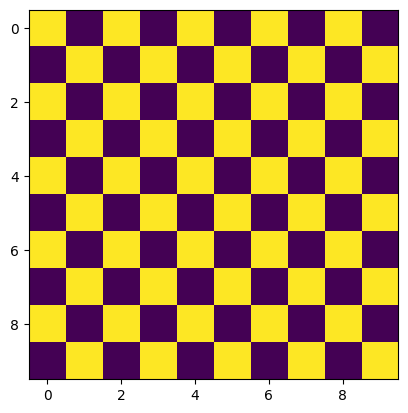

In [61]:
h, v, d = patrones_balanceados(10, 10)
plt.imshow(d)

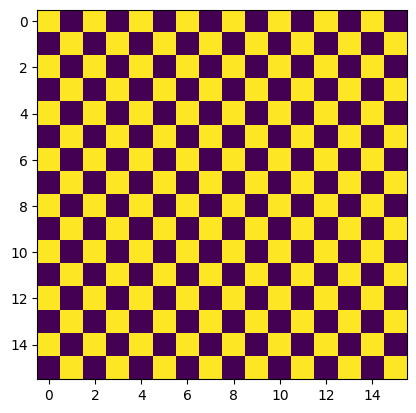

In [62]:
n = 16
m = 16
N = n*m
h, v, d = patrones_balanceados(n, m)
plt.imshow(d)

Cálculo de los $\xi^\mu$

In [63]:
psi = np.zeros((3,N))
psi[0] = np.concat(h)
psi[1] = np.concat(v)
psi[2] = np.concat(d)

Cálculo de la matríz Wij

In [64]:
def pesos(psi, N):
  W = np.zeros((N,N))
  for i in range(0,N):
    for j in range (0,N):
      if i != j:
        wij = psi[0][i]*psi[0][j] + psi[1][i]*psi[1][j] + psi[2][i]*psi[2][j]
        W[i,j] = wij

  return W


Energía

In [65]:
def campo (W, estado):
  return W@np.concat(estado)/N


def energia (estado, campo):
  return -0.5*np.concat(estado).T@campo

In [66]:
Hh = campo(W, h)
Hv = campo(W, v)


Eh = energia(h, Hh)
Ev = energia(v, Hv)

print(Eh)
print(Ev)

-126.5
-126.5


Imagen con ruido

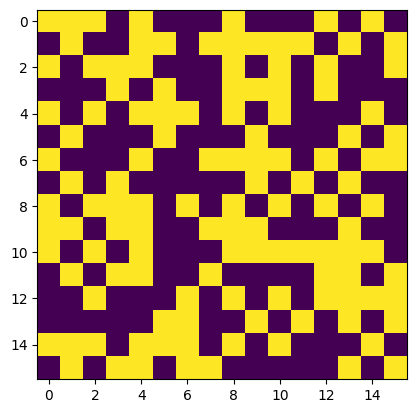

In [67]:
s_ruido = agregar_ruido(d.flatten(), frac=0.25, seed=10)
plt.imshow(np.reshape(s_ruido, (n, m)))

In [68]:
Hr = campo(W, s_ruido)
Er = energia(s_ruido, Hr)
print(Er)

ValueError: zero-dimensional arrays cannot be concatenated

# Imagen 2

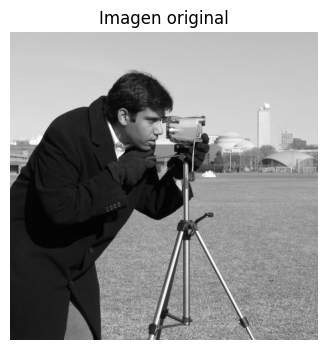

In [69]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

img = data.camera()   # imagen 512x512 en escala de grises

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

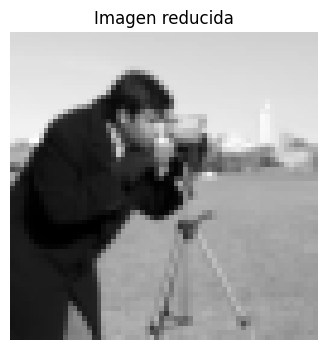

In [70]:
# ============================================================
# Reducir imagen
# ============================================================

n = 64
m = 64

img_small = resize(img, (n, m), anti_aliasing=True)

plt.figure(figsize=(4,4))
plt.imshow(img_small, cmap="gray")
plt.title("Imagen reducida")
plt.axis("off")
plt.show()

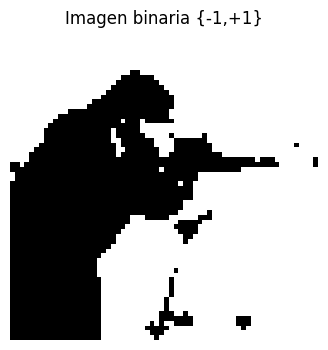

In [71]:
# ============================================================
# Binarización
# ============================================================

threshold = img_small.mean()

img_bin = np.where(img_small > threshold, 1, -1)

plt.figure(figsize=(4,4))
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binaria {-1,+1}")
plt.axis("off")
plt.show()

In [72]:
img_bin

array([[ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       ...,
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1]])

## Implementación de los pasos para Imagen 2

Aquí implementaremos las funciones necesarias y el proceso de recuperación para la `img_bin` obtenida de la imagen de la cámara.

### 1. Convertir una imagen binaria en un vector de estados
La `img_bin` ya está en el formato `{-1, 1}`. Solo necesitamos aplanarla para obtener el vector de estados.

In [75]:
s_original = img_bin.flatten()
N_img2 = len(s_original)
print(f"Dimension del vector de estado: {N_img2}")

Dimension del vector de estado: 4096


### 2. Calcular la matriz de pesos de Hopfield
Usaremos la regla de Hebb para un solo patrón.

In [76]:
def calcular_matriz_pesos(pattern, N):
    W = np.outer(pattern, pattern) # Calcula xi * xj
    np.fill_diagonal(W, 0)       # Establece la diagonal a cero (w_ii = 0)
    return W / N                 # Aplica el factor 1/N

W_img2 = calcular_matriz_pesos(s_original, N_img2)

print(f"Dimension de la matriz de pesos: {W_img2.shape}")

Dimension de la matriz de pesos: (4096, 4096)


### 3. Calcular el campo local que siente una neurona
El campo local para una neurona $i$ es la suma ponderada de los estados de las otras neuronas.

In [77]:
def calcular_campo_local_neurona(W, state_vector, neuron_idx):
    return np.dot(W[neuron_idx, :], state_vector)

### 4. Actualizar el estado de una neurona
La actualización se basa en la función `sign(h_i)`. Si el campo local es cero, la neurona mantiene su estado actual.

In [78]:
def actualizar_estado_neurona(local_field, current_state_i):
    if local_field > 0:
        return 1
    elif local_field < 0:
        return -1
    else: # local_field == 0
        return current_state_i # Mantiene el estado actual

### 5. Calcular la energía total de la red
La energía se calcula como $E(s)=-\frac{1}{2}s^TWs$.

In [79]:
def calcular_energia_red(W, state_vector):
    return -0.5 * np.dot(state_vector.T, np.dot(W, state_vector))

### 6. Aplicar ruido a una imagen
Esta función ya ha sido definida y utilizada previamente en el notebook. Volveremos a usarla aquí con la imagen binarizada.

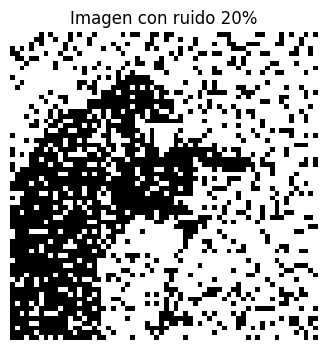

In [80]:
frac_ruido_img2 = 0.20 # Nivel de ruido para la recuperación
s_ruido_img2 = agregar_ruido(s_original, frac=frac_ruido_img2, seed=42)

plt.figure(figsize=(4,4))
plt.imshow(s_ruido_img2.reshape(n, m), cmap="gray")
plt.title(f"Imagen con ruido {frac_ruido_img2*100:.0f}%")
plt.axis("off")
plt.show()

### 7. Recuperar la imagen mediante actualización asincrónica aleatoria
Se seleccionan neuronas aleatoriamente y se actualiza su estado hasta que la red se estabilice o se alcance un número máximo de iteraciones.

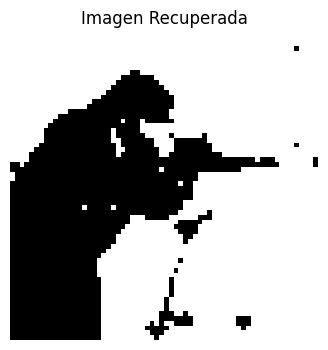

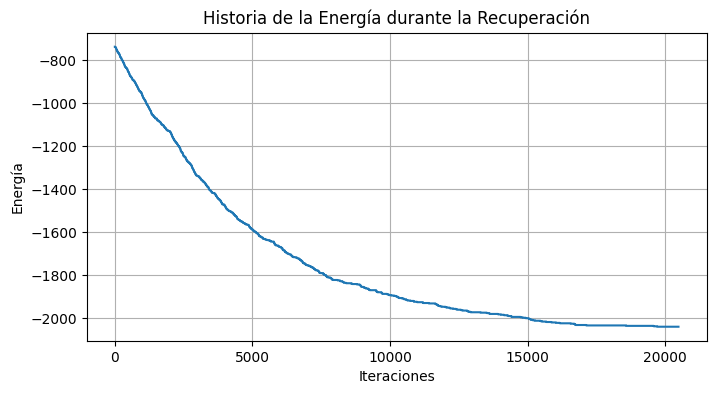

In [81]:
def recuperar_imagen_hopfield(initial_state, W, N_neurons, n_iterations=None, tol=1e-6):
    current_state = np.copy(initial_state)
    energy_history = []

    if n_iterations is None:
        n_iterations = N_neurons * 5 # Default iterations based on number of neurons

    for iteration in range(n_iterations):
        # Calcular energía actual y guardarla
        current_energy = calcular_energia_red(W, current_state)
        energy_history.append(current_energy)

        # Seleccionar una neurona aleatoriamente
        idx_to_update = np.random.randint(N_neurons)

        # Calcular el campo local para la neurona seleccionada
        local_field = calcular_campo_local_neurona(W, current_state, idx_to_update)

        # Actualizar el estado de la neurona
        old_neuron_state = current_state[idx_to_update]
        new_neuron_state = actualizar_estado_neurona(local_field, old_neuron_state)

        current_state[idx_to_update] = new_neuron_state

        # Comprobar la convergencia de la energía (opcional, pero útil)
        if iteration > 0 and abs(energy_history[-1] - energy_history[-2]) < tol:
            # Si la energía no ha cambiado significativamente, la red ha convergido
            # Pero en la actualización asíncrona, cada cambio de neurona modifica la energía,
            # por lo que es mejor verificar si el estado global se estabiliza.
            # Una forma simple es ver si no hay cambios en la última 'N' iteraciones.
            pass # Simplificado para este ejemplo, el criterio de parada principal es el número de iteraciones

    return current_state, energy_history

# Recuperar la imagen
recovered_s_img2, energy_trace_img2 = recuperar_imagen_hopfield(s_ruido_img2, W_img2, N_img2)

# Visualizar la imagen recuperada
plt.figure(figsize=(4,4))
plt.imshow(recovered_s_img2.reshape(n, m), cmap="gray")
plt.title("Imagen Recuperada")
plt.axis("off")
plt.show()

# Visualizar la historia de la energía
plt.figure(figsize=(8, 4))
plt.plot(energy_trace_img2)
plt.xlabel("Iteraciones")
plt.ylabel("Energía")
plt.title("Historia de la Energía durante la Recuperación")
plt.grid(True)
plt.show()